In [25]:
!pip install -q qdrant-client sentence-transformers docling groq docling-hierarchical-pdf

In [27]:
import os

from docling.document_converter import DocumentConverter
from docling_core.transforms.chunker import HierarchicalChunker
from hierarchical.postprocessor import ResultPostprocessor

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)
from groq import Groq

### **What is Docling?**
A document parser and loader built specifically for AI Applications by IBM. It parses, converts, and structures complex, unstructured documents (such as PDFs, DOCX, and images) into machine-readable formats like Markdown or JSON.

### **Why do we need to use Docling?**
**90%** of enterprise related documents are unstructured in file formats like PDF, DOCX, HTML etc.

And ingestion quality is really important for a RAG Pipeline.


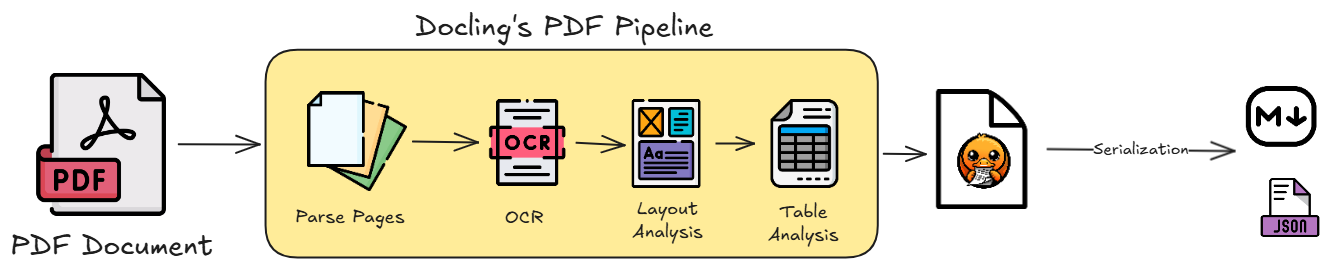

In [34]:
SOURCE = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/AtliqAI_HR_Policies.pdf"

def load_document(source: str):
    """
    Parse a PDF using Docling.
    Returns a DoclingDocument object — not a plain string.
    """
    converter = DocumentConverter()
    result = converter.convert(source)
    ResultPostprocessor(result).process()
    return result.document

doc = load_document(SOURCE)
print(f"Document loaded: {doc.name}")

[INFO] 2026-03-15 11:40:03,701 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-15 11:40:03,702 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-15 11:40:03,752 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-15 11:40:03,753 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-15 11:40:04,019 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-15 11:40:04,021 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-15 11:40:04,026 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-15 11:40:04,028 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-15 11:40:04,131 [RapidO

Document loaded: AtliqAI_HR_Policies


In [35]:
markdown_doc = doc.export_to_markdown()

print(markdown_doc[:1000])

## AtliqAI HR Policies

AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-being at AtliqAI. All employees are expected to read, understand, and adhere to these policies from their first day of joining.

### Employment &amp; Onboarding

#### Offer and Joining Formalities

Upon acceptance of an offer letter, candidates must complete the joining formalities within the stipulated date mentioned in the offer. The HR team will share a prejoining checklist that includes submission of educational certificates, identity proof, address proof, previous employment documents, and a recent photograph. Failure to submit required documents within 7 working days of joining may result in withholding of the first salary disbursement.

#### Probation Period

All new employees at AtliqAI are placed on a probation period of 6 months from the date of joining. Dur

### **Chunking**
It's an essential preprocessing step where we break down large documents into smaller, manageable, and semantically meaningful text segments.

It optimizes RAG by ensuring retrieval accuracy, fitting content into LLM context windows, and reducing retrieval time.

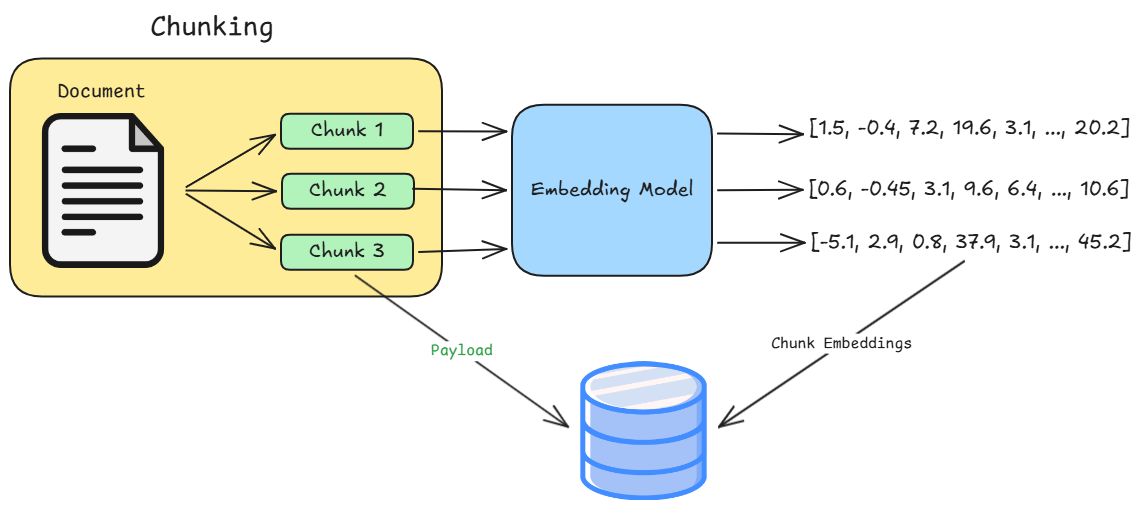





### **What is Heirarchial Chunking?**

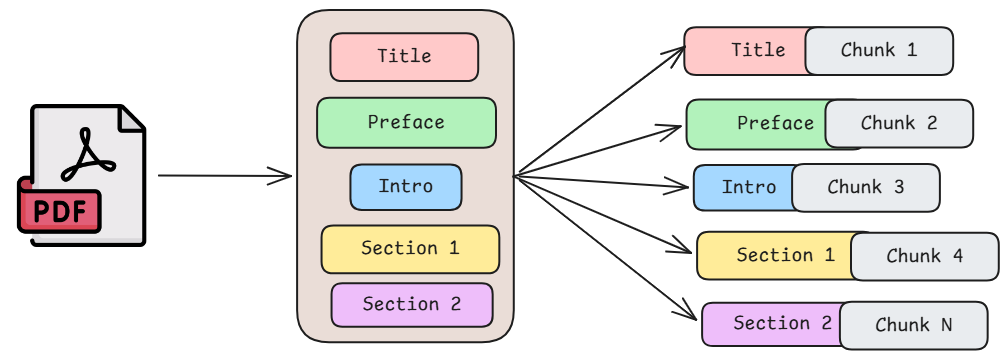

In [39]:
chunker   = HierarchicalChunker()
doc_chunks = list(chunker.chunk(doc))

print(f"Total chunks: {len(doc_chunks)}")

# Inspect a raw DocChunk
sample = doc_chunks[2]
print(f"headings : {sample.meta.headings}")
print(f"text     : {sample.text[:200]}…")

Total chunks: 45
headings : ['AtliqAI HR Policies', 'Employment & Onboarding', 'Probation Period']
text     : All new employees at AtliqAI are placed on a probation period of 6 months from the date of joining. During this period, either party may terminate the employment with a notice period of 15 days. Perfo…


### **Transformation: We need to convert our chunk to this format:**
```json
{
    "headings":   ['AtliqAI HR Policies', 'Employment & Onboarding', 'Probation Period'],
    "content":    "All new employees at AtliqAI are placed on a probation period of 6 months from...",
    "chunk_text": "AtliqAI HR Policies > Employment & Onboarding > Probation Period\n\nAll new employees at AtliqAI are placed on a probation period of 6 months from..."
}
```

In [12]:
def convert_chunk(doc_chunk) -> dict:
    """
    Convert a Docling DocChunk into a plain dict.

    headings   → list preserved as-is
    content    → paragraph text
    chunk_text → breadcrumb + content  (what gets embedded)
    """
    headings   = doc_chunk.meta.headings or []
    content    = doc_chunk.text.strip()
    breadcrumb = " > ".join(headings)
    chunk_text = f"{breadcrumb}\n\n{content}" if breadcrumb else content

    return {
        "headings":   headings,
        "content":    content,
        "chunk_text": chunk_text,
    }

chunks = [convert_chunk(c) for c in doc_chunks]

In [13]:
for chunk in chunks[:3]:
    print("─" * 60)
    print(f"headings   : {chunk['headings']}")
    print(f"content    : {chunk['content'][:200]}…")

────────────────────────────────────────────────────────────
headings   : ['AtliqAI HR Policies']
content    : AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-be…
────────────────────────────────────────────────────────────
headings   : ['AtliqAI HR Policies', 'Employment & Onboarding', 'Offer and Joining Formalities']
content    : Upon acceptance of an offer letter, candidates must complete the joining formalities within the stipulated date mentioned in the offer. The HR team will share a prejoining checklist that includes subm…
────────────────────────────────────────────────────────────
headings   : ['AtliqAI HR Policies', 'Employment & Onboarding', 'Probation Period']
content    : All new employees at AtliqAI are placed on a probation period of 6 months from the date of joining. During this period, either party may terminate the emplo

### **Embedding**
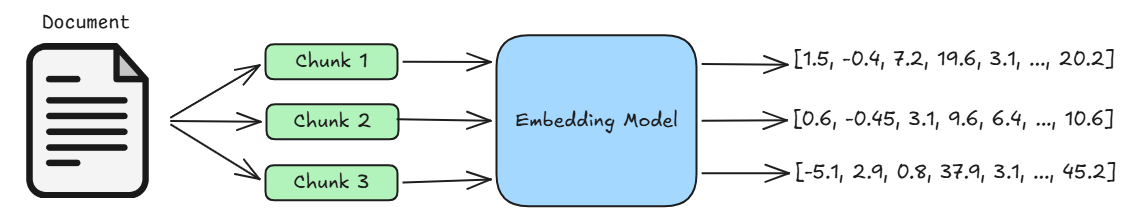

In [14]:
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

chunk_texts = [c["chunk_text"] for c in chunks]

print(f"Embedding {len(chunk_texts)} chunks …")
embeddings = embedder.encode(chunk_texts, show_progress_bar=True)

print(f"Shape: {embeddings.shape}")   # → (N, 384)

Embedding 45 chunks …


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Shape: (45, 384)


### **Indexing**

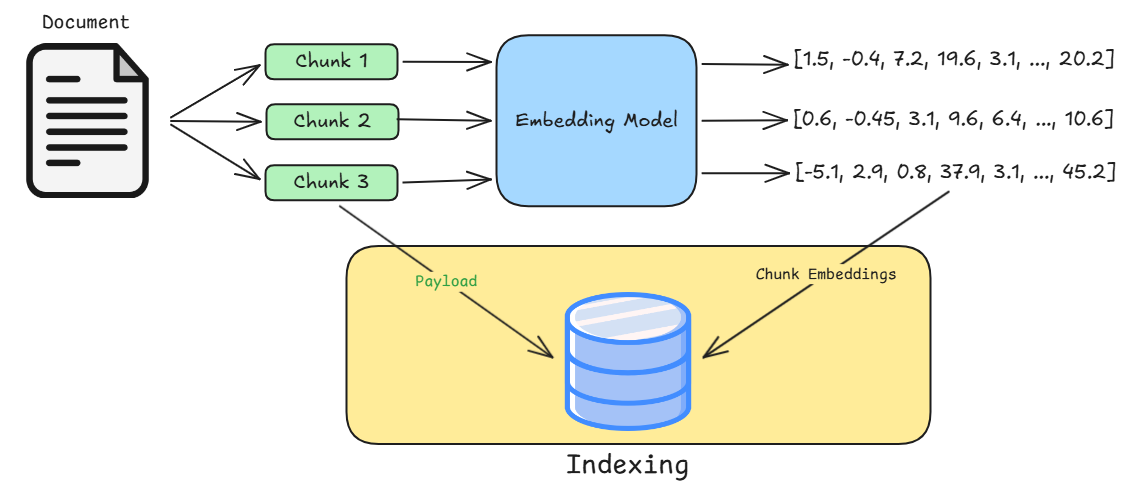

In [15]:
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

# "path" = no server needed for demos
# Production use: QdrantClient(url="http://localhost:6333")
client = QdrantClient(path="/tmp/my_qdrant")

COLLECTION_NAME = "docs"
DIM = embedder.get_sentence_embedding_dimension()

client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=DIM,
        distance=Distance.COSINE,
    ),
)
print("Collection created.")

Collection created.


/tmp/ipykernel_386/472045.py:14: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


In [16]:
# Creating Points

points = [
    PointStruct(
        id=idx,
        vector=embedding.tolist(),
        payload={
            "headings":   chunk["headings"],   # stored as a JSON array
            "content":    chunk["content"],
            "chunk_text": chunk["chunk_text"],
        },
    )
    for idx, (chunk, embedding) in enumerate(zip(chunks, embeddings))
]

result = client.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
    wait=True,
)
print(f"Indexed {len(points)} points — status: {result.status}")

Indexed 45 points — status: completed


In [17]:
info = client.get_collection(COLLECTION_NAME)
print(f"Points     : {info.points_count}")
print(f"Dimensions : {info.config.params.vectors.size}")

Points     : 45
Dimensions : 384


## **Retrieval**

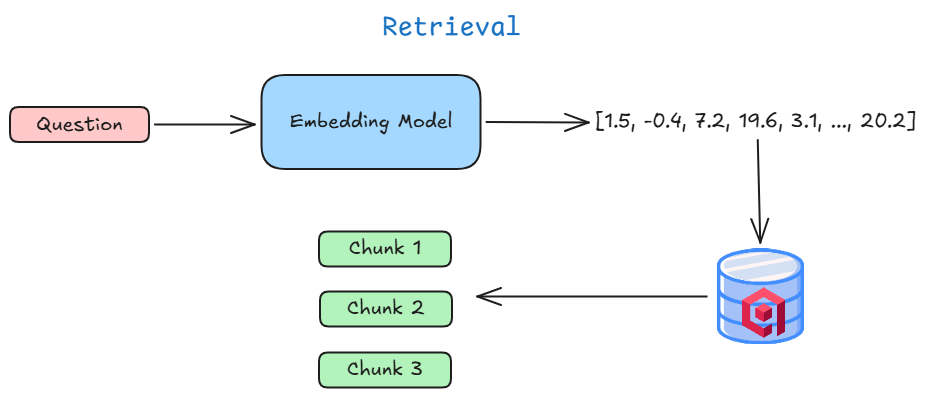

In [18]:
def retrieve(
    query: str,
    top_k: int = 5
) -> list[dict]:
    """
    Embed the query and return the top-k most similar chunks.

    Args:
        query          : User's question.
        top_k          : Number of chunks to return.
        section_filter : Optional H2 heading to restrict the search scope.
    """
    query_vector = embedder.encode(query).tolist()

    hits = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k,
        with_payload=True,
    )

    return [{**hit.payload, "score": round(hit.score, 4)} for hit in hits.points]

In [19]:
results = retrieve("What is the leave policy?", top_k=3)
for r in results:
    print(f"[{r['score']}]  {r['headings']}")
    print(f"  {r['content'][:200]}…\n")

[0.5195]  ['AtliqAI HR Policies', 'Leave Policy', 'Leave Without Pay']
  Employees who exhaust all available leave balances may apply for leave without pay (LWP). LWP must be approved by the reporting manager and HR. More than 10 days of LWP in a financial year may impact …

[0.5109]  ['AtliqAI HR Policies', 'Leave Policy', 'Casual Leave']
  Every confirmed employee is entitled to 12 casual leaves per calendar year, credited at 1 leave per month. Casual leave can be availed for personal errands, minor illness, or unplanned absences. A max…

[0.499]  ['AtliqAI HR Policies', 'Leave Policy', 'Sick Leave']
  Employees are entitled to 10 sick leaves per calendar year. Sick leave can be availed in case of illness, hospitalisation, or medical procedures. A medical certificate from a registered practitioner i…



## **RAG Pipeline**

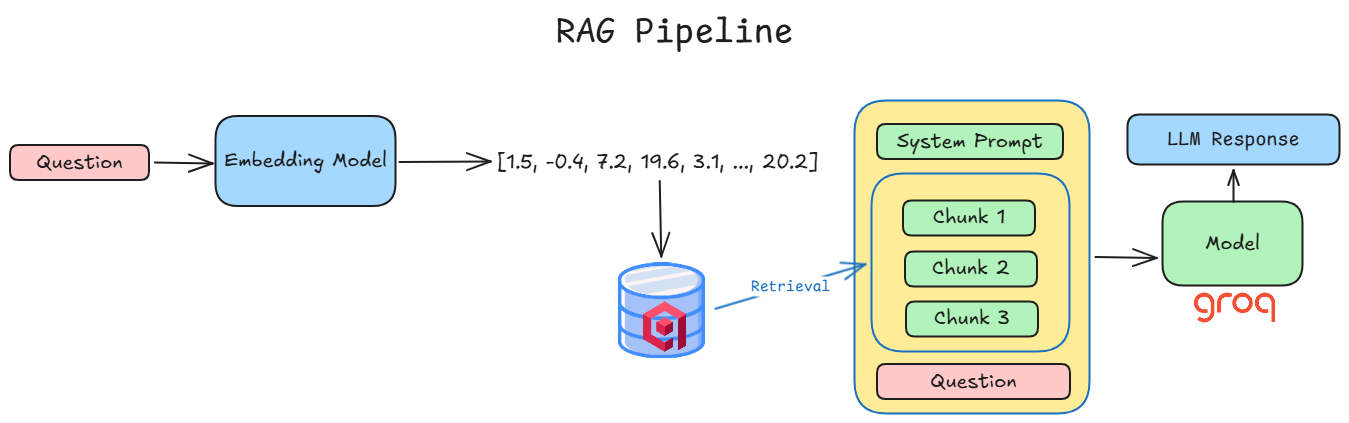

In [20]:
SYSTEM_PROMPT = """You are a helpful HR assistant.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information."""

In [21]:
def build_context(retrieved_chunks: list[dict]) -> str:
    parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        parts.append(f"[Source {i}]\n{chunk['content']}")
    return "\n\n---\n\n".join(parts)

In [22]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

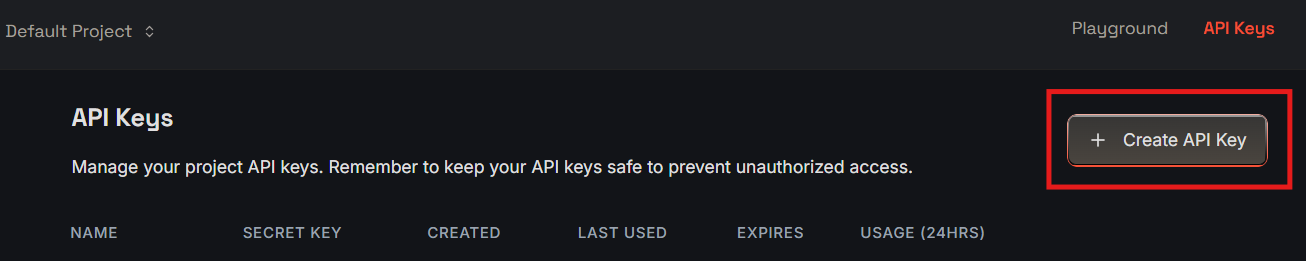

In [23]:
from groq import Groq

groq_client = Groq()   # Reads GROQ_API_KEY from environment automatically
GROQ_MODEL  = "openai/gpt-oss-safeguard-20b"

def rag(query: str, top_k: int = 5):
    """
    End-to-end RAG pipeline:
      1. Retrieve relevant chunks from Qdrant
      2. Format them as a context block
      3. Send context + query to Groq and return the answer
    """
    # Step 1 — Retrieve
    chunks = retrieve(query, top_k=top_k)
    if not chunks:
        return "No relevant content found in the document."

    # Step 2 — Build context
    context = build_context(chunks)

    # Step 3 — Generate
    user_message = f"Context:\n{context}\n\nQuestion: {query}"

    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.2,   # Low = factual;  High = creative
    )
    return response.choices[0].message.content, context

In [24]:
answer, context = rag("How many casual leaves am I entitled to?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

You are entitled to **12 casual leaves per calendar year** (credited at 1 leave per month). This is stated in Source 1.


SOURCES:
 [Source 1]
Every confirmed employee is entitled to 12 casual leaves per calendar year, credited at 1 leave per month. Casual leave can be availed for personal errands, minor illness, or unplanned absences. A maximum of 3 consecutive casual leaves can be taken at a time. Casual leaves cannot be carried forward to the next calendar year and lapse on December 31st.

---

[Source 2]
Employees are entitled to 10 sick leaves per calendar year. Sick leave can be availed in case of illness, hospitalisation, or medical procedures. A medical certificate from a registered practitioner is mandatory for sick leave of more than 2 consecutive days. Unused sick leaves up to a maximum of 10 can be carried forward to the following year.

---

[Source 3]
Employees accrue earned leave at the rate of 1.25 days per month, amounting to 15 days per year. Earned leave can be carri